<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


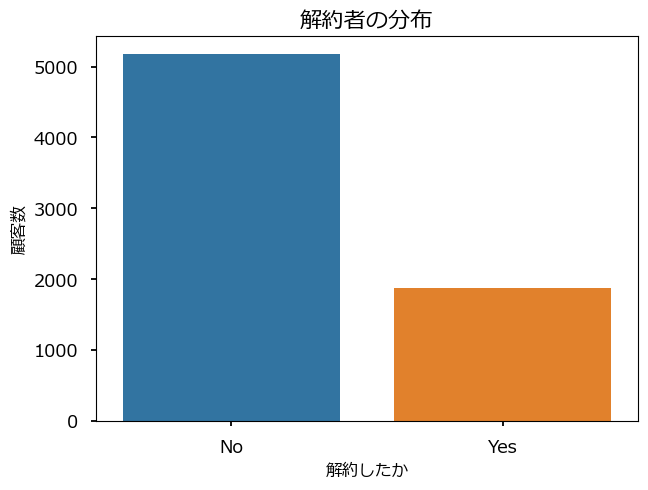

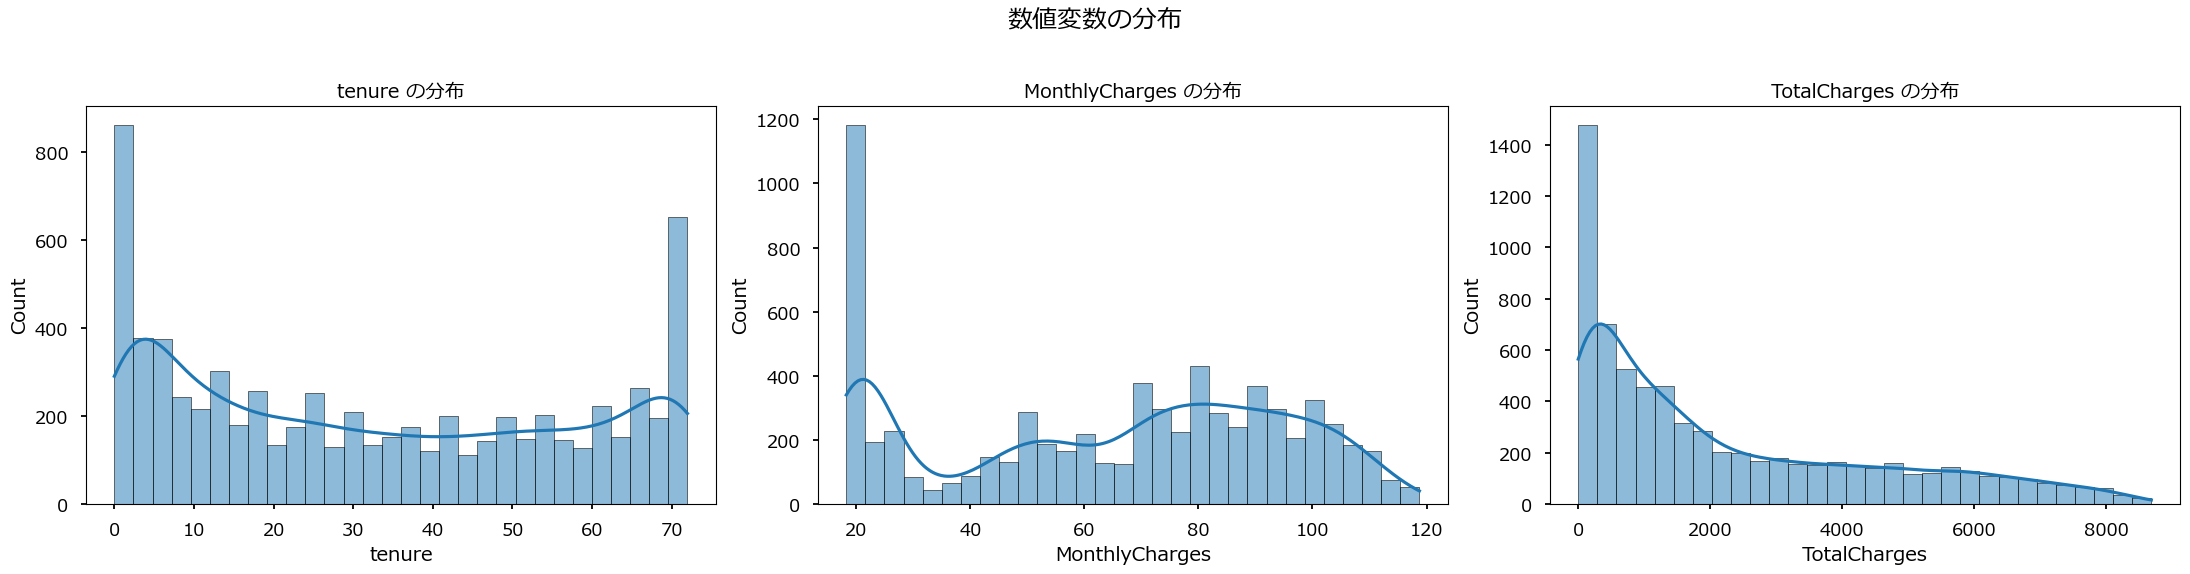

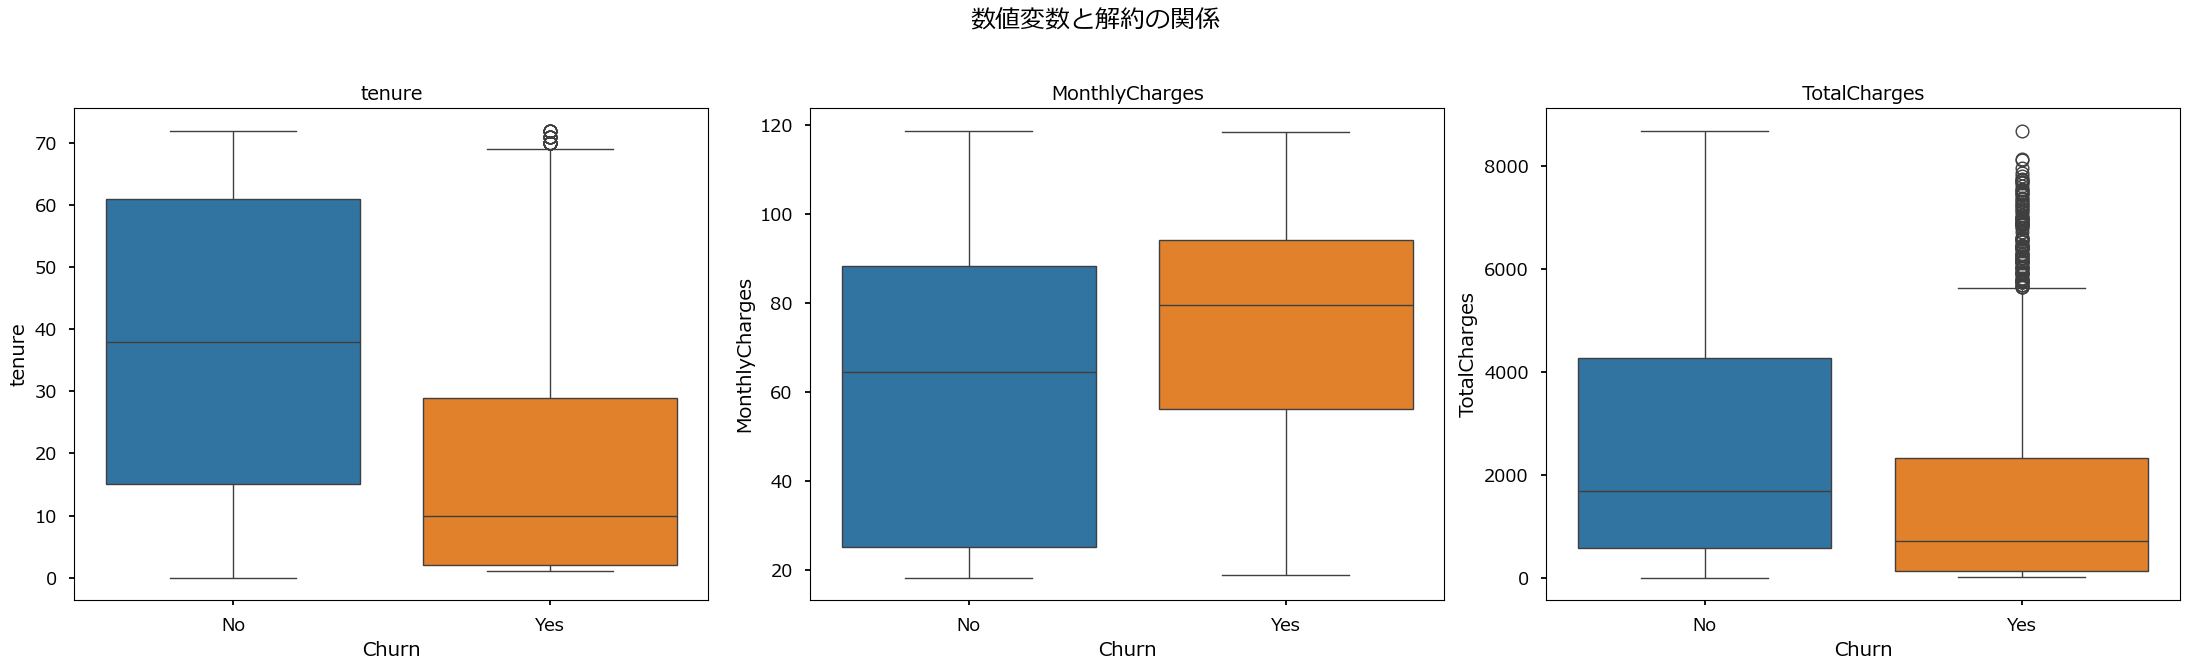

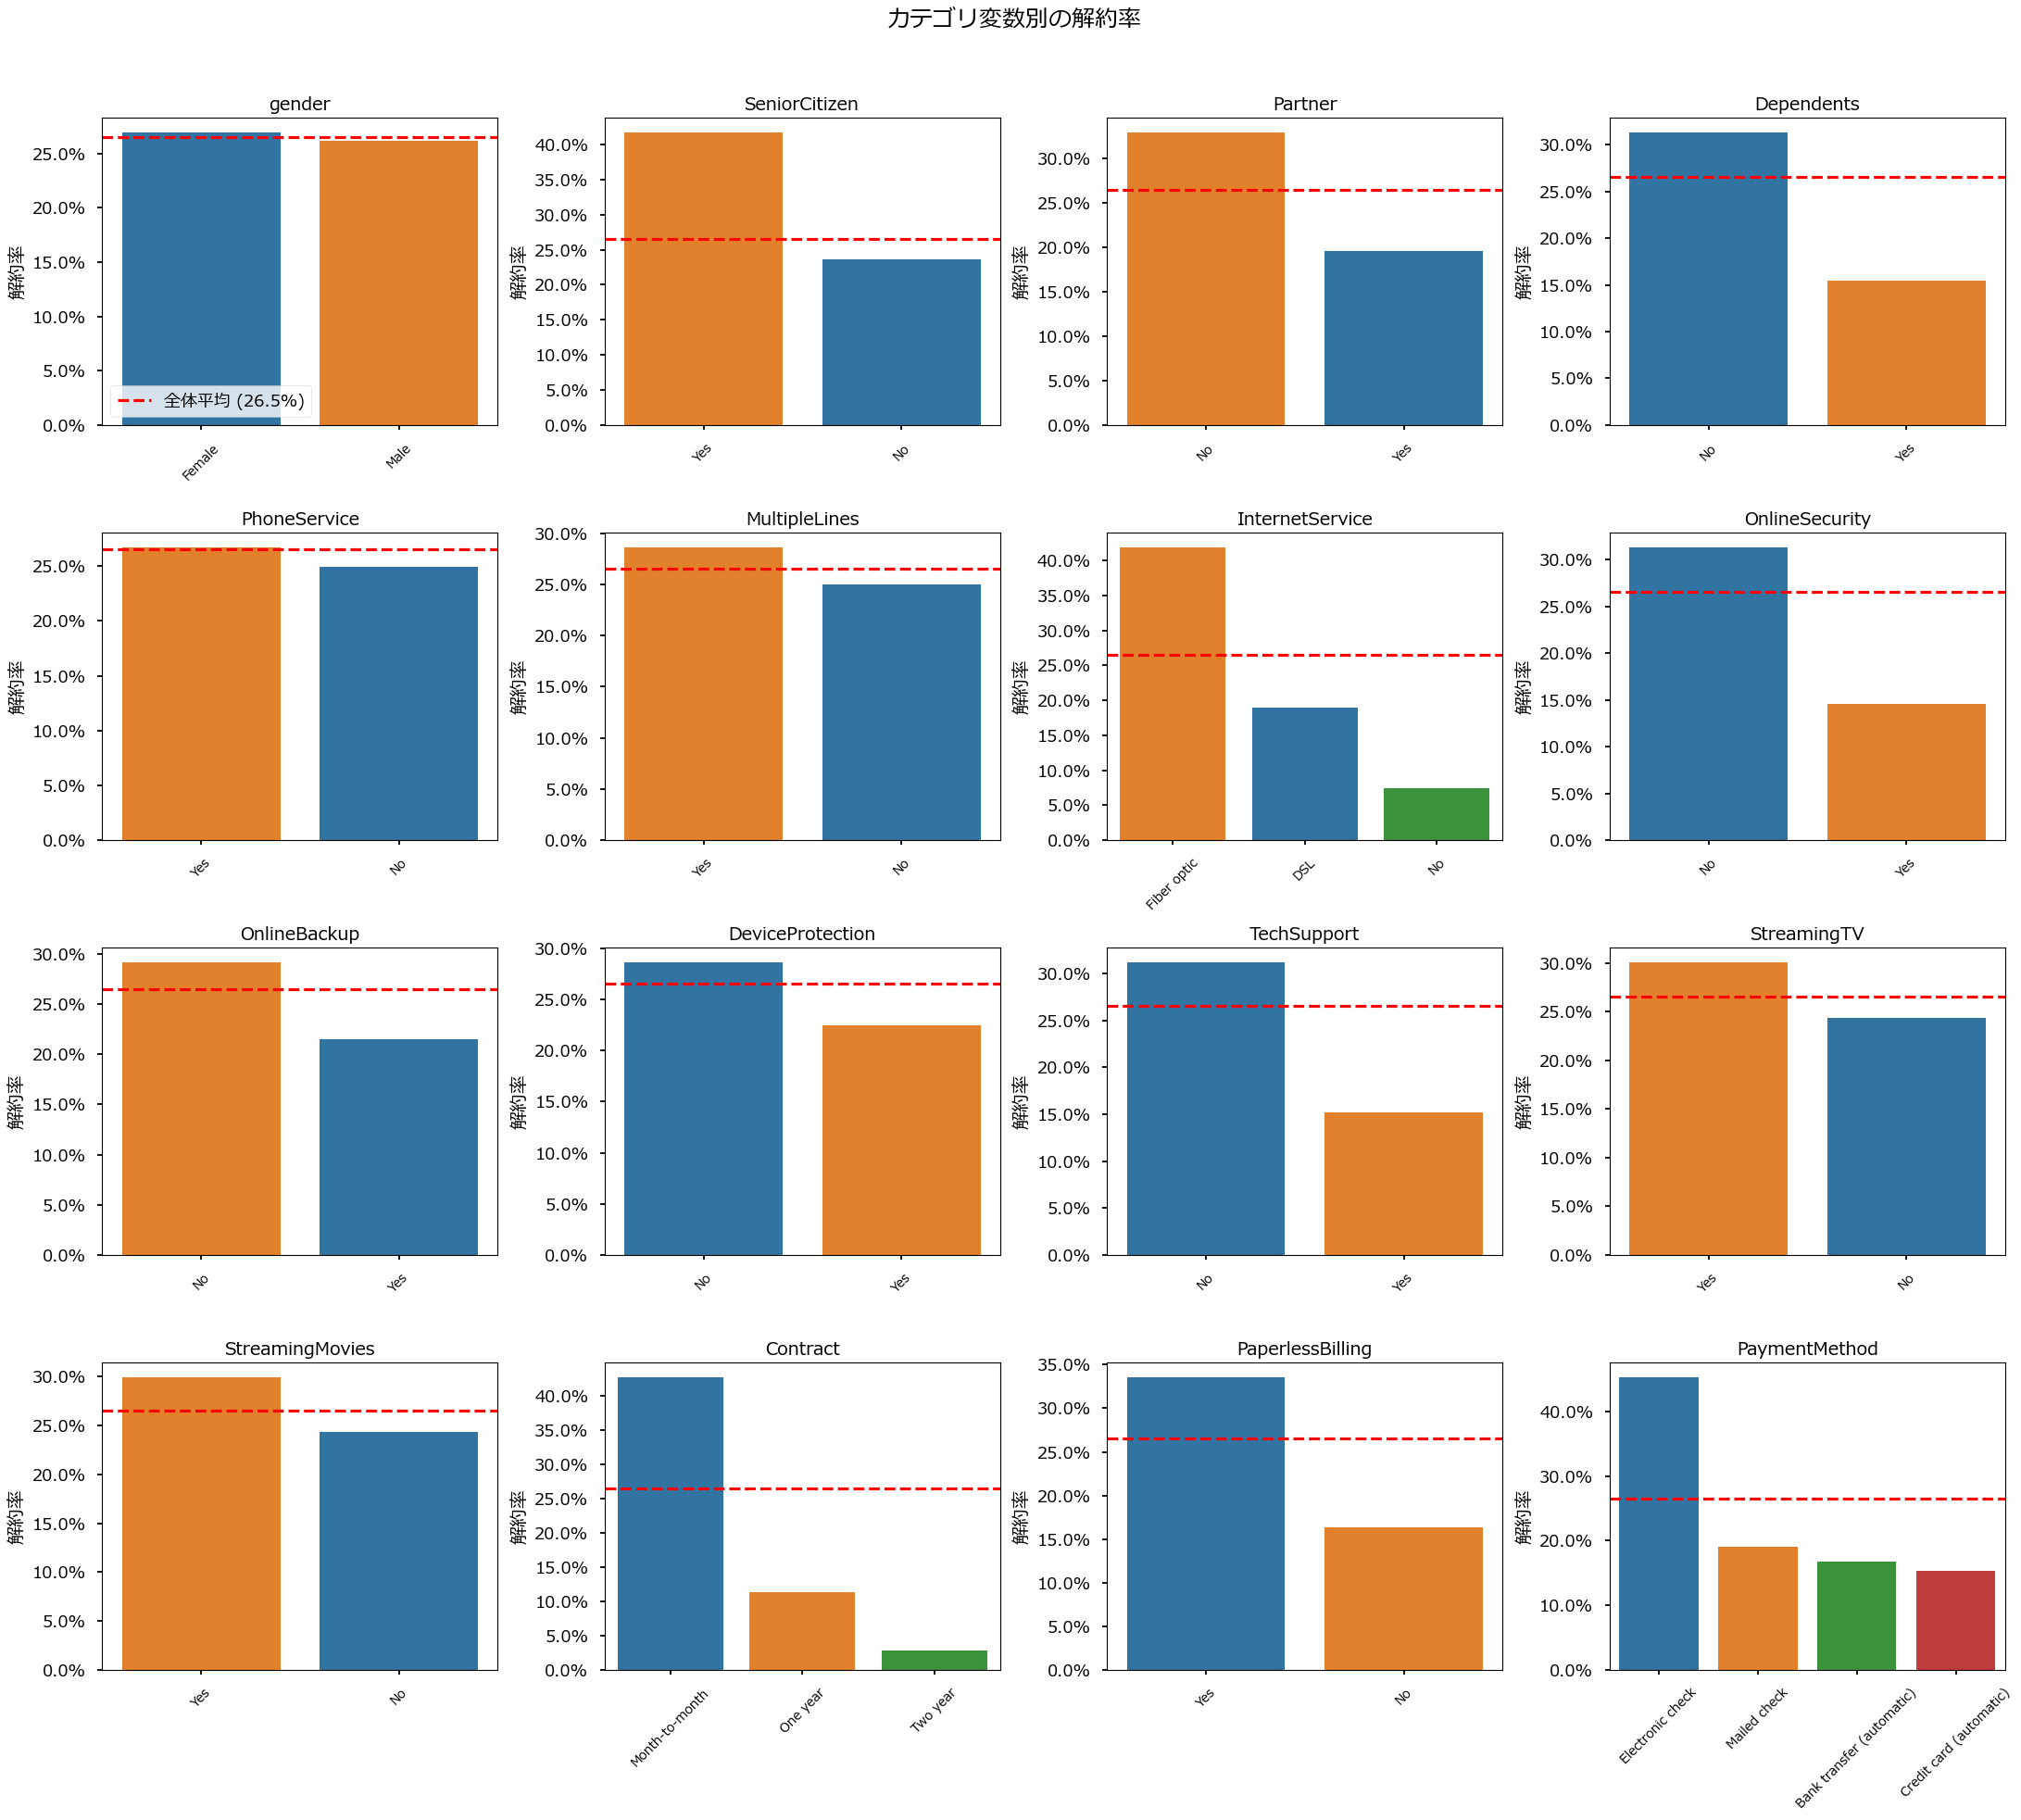

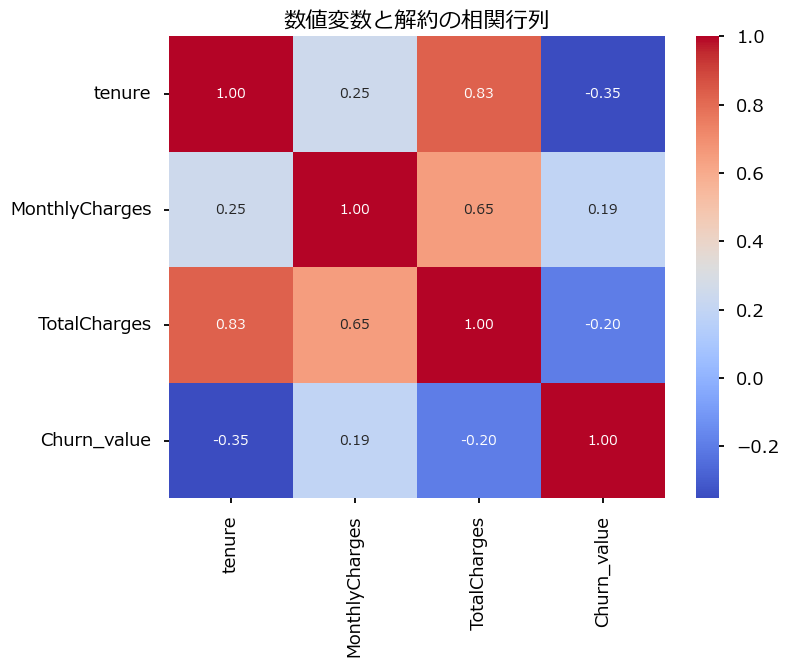

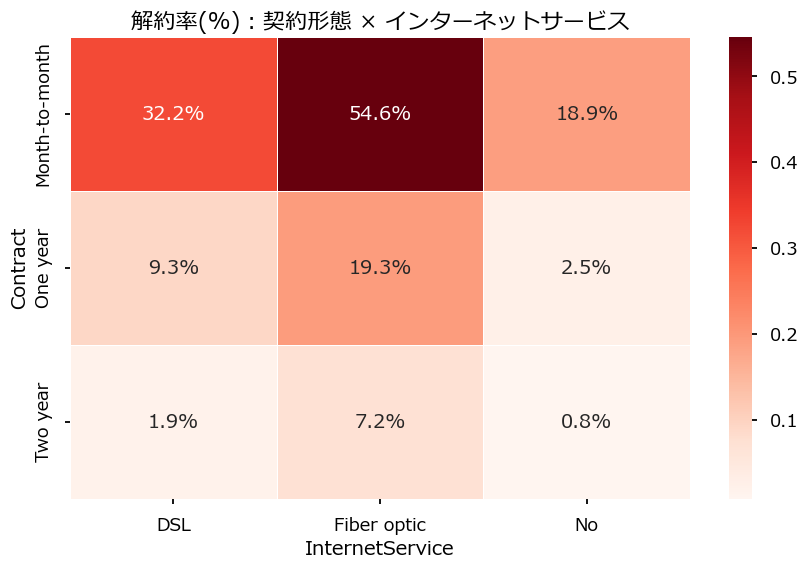

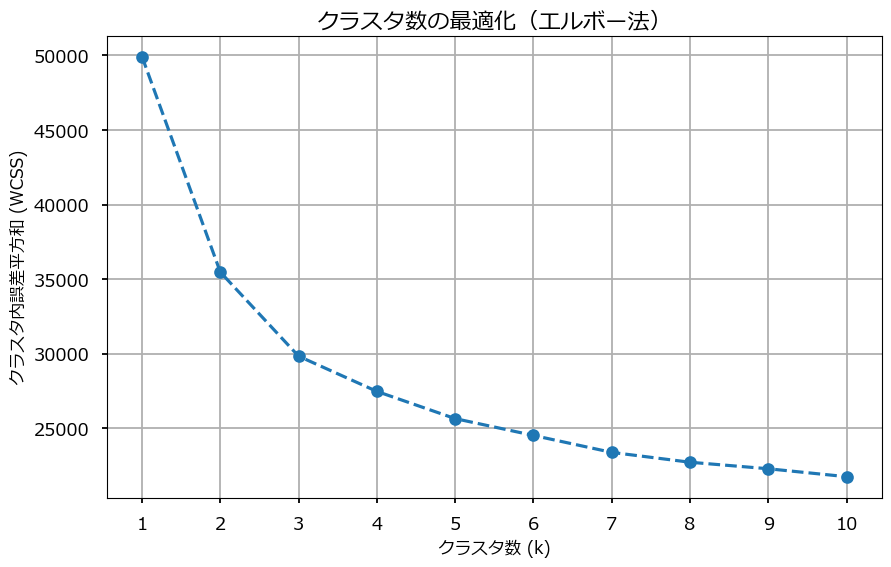

各クラスタの顧客数と解約率 (k=4) 
|   クラスタ番号 |   customer_count |   churn_rate |
|---------------:|-----------------:|-------------:|
|              1 |             2220 |    0.501802  |
|              2 |             1748 |    0.240275  |
|              3 |             1902 |    0.147213  |
|              4 |             1173 |    0.0468883 |


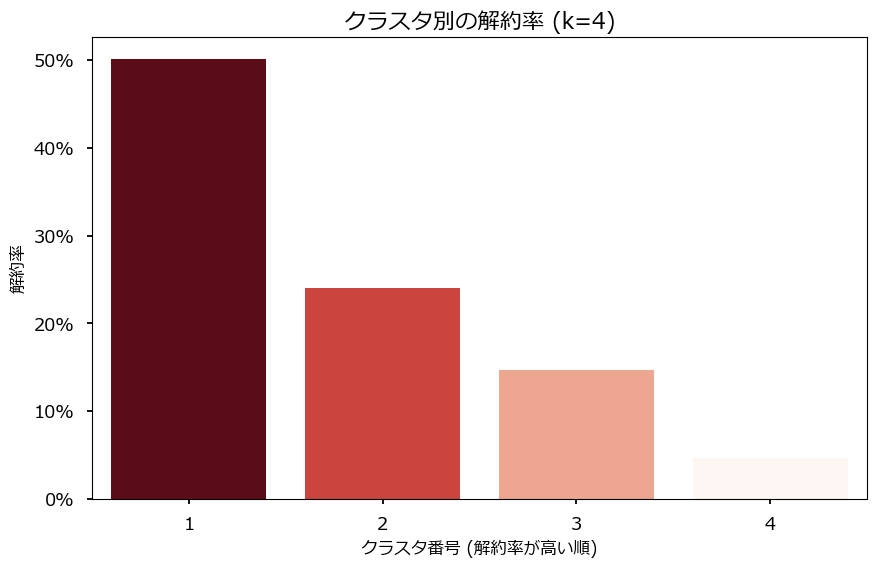

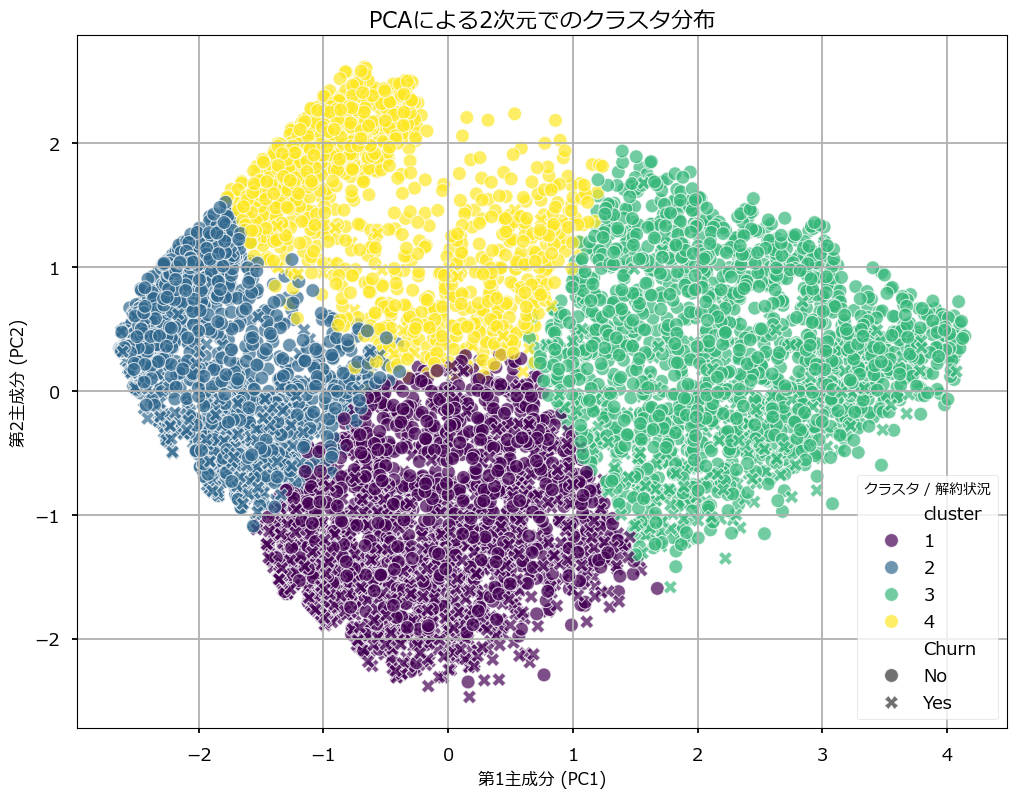

: ハイリスク・クラスタ 1 
|                |   ハイリスク・クラスタ 1 |   顧客全体 |
|:---------------|-------------------------:|-----------:|
| tenure         |                    15.56 |      32.37 |
| MonthlyCharges |                    81.45 |      64.76 |
| TotalCharges   |                  1278.68 |    2279.73 |

--- Contract の内訳比較 ---
| Contract       |   ハイリスク・クラスタ 1 (%) |   顧客全体 (%) |
|:---------------|-----------------------------:|---------------:|
| Month-to-month |                         89.2 |           55   |
| One year       |                          9.4 |           20.9 |
| Two year       |                          1.4 |           24.1 |

--- PaymentMethod の内訳比較 ---
| PaymentMethod             |   ハイリスク・クラスタ 1 (%) |   顧客全体 (%) |
|:--------------------------|-----------------------------:|---------------:|
| Bank transfer (automatic) |                         15.2 |           21.9 |
| Credit card (automatic)   |                         13.5 |           21.6 |
| Electronic check          |  

In [24]:
#ライブラリ
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter　#パーセント表示
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
#日本語フォントを治す
plt.rcParams['font.family'] = 'Meiryo'

#csv読み込み
df = pd.read_csv("C:/Users/jorda/Kaggle_02/WA_Fn-UseC_-Telco-Customer-Churn_copy.csv")

#Phase2 前処理 
#データ確認
df.info()
print(df.head())
print(df.describe())

#0カ月?
#TotalChargesが数値ではなくobject型。これは計算できないため修正が必要。
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# 欠損値(NaN)を0で補完
df.fillna({'TotalCharges': 0}, inplace=True)
print(f"TotalChargesを数値に変換した後の欠損値の数: {df['TotalCharges'].isnull().sum()}件")

#どちらもNoを意味する
df.replace(['No phone service', 'No internet service'], 'No', inplace=True)
#0,1をNo,Yesに変換して形式をそろえる
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

#目的変数を0,1に変換。解約率を出すように
df['Churn_value'] = df['Churn'].map({'Yes': 1, 'No': 0})

#予測モデルには不要だが、クラスタリングを採用したのでのちに必要になるかも?
df.drop('customerID', axis=1, inplace=True)
#print(df.head())

#Phase3:EDA 
#全体の解約率
overall_churn_rate = df['Churn_value'].mean()
print(f"全体の解約率: {overall_churn_rate:.2%}")

plt.figure(figsize=(7, 5))
sns.countplot(x='Churn', data=df, hue='Churn', legend=False)
plt.title('解約者の分布', fontsize=16)
plt.xlabel('解約したか', fontsize=12)
plt.ylabel('顧客数', fontsize=12)
plt.show()

#2.数値変数の分布
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('数値変数の分布', fontsize=18)
for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'{col} の分布', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#3.二変量
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('数値変数と解約の関係', fontsize=18)
for i, col in enumerate(numerical_features):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[i], hue='Churn', legend=False)
    axes[i].set_title(f'{col}', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#カテゴリ変数 vs 解約
fig, axes = plt.subplots(4, 4, figsize=(22, 20))
fig.suptitle('カテゴリ変数別の解約率', fontsize=18)
axes = axes.flatten()
for i, col in enumerate(categorical_features):
    order = df.groupby(col)['Churn_value'].mean().sort_values(ascending=False).index
    sns.barplot(x=col, y='Churn_value', data=df, ax=axes[i], errorbar=None, hue=col, legend=False, order=order)
    axes[i].axhline(y=overall_churn_rate, color='r', linestyle='--', label=f'全体平均 ({overall_churn_rate:.1%})')
    axes[i].set_title(f'{col}', fontsize=14)
    axes[i].tick_params(axis='x', labelrotation=45, labelsize=10)
    axes[i].yaxis.set_major_formatter(PercentFormatter(1.0))
    axes[i].set_xlabel('')
    axes[i].set_ylabel('解約率')
    if i == 0: axes[i].legend()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#4. 説明変数同士の関係
plt.figure(figsize=(8, 6))
correlation_matrix = df[numerical_features + ['Churn_value']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('数値変数と解約の相関行列', fontsize=16)
plt.show()

#5. a x b 
cross_rate = pd.crosstab(df['Contract'], df['InternetService'], values=df['Churn_value'], aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(cross_rate, annot=True, fmt='.1%', cmap='Reds', linewidths=.5, annot_kws={"size": 14})
plt.title('解約率(%)：契約形態 × インターネットサービス', fontsize=16)
plt.show()




# Phase4 k-means 
#4-1. クラスタリングのためのデータ準備
df_cluster_input = df.drop(['Churn', 'Churn_value', 'cluster'], axis=1, errors='ignore') 
#教師なし学習なので、目的変数を消しておく
df_cluster_dummies = pd.get_dummies(df_cluster_input, drop_first=True)
#0,1
scaler = StandardScaler()
df_cluster_dummies[numerical_features] = scaler.fit_transform(df_cluster_dummies[numerical_features])
#標準化で単位を揃える

#4-2. エルボー法
wcss = []
k_range = range(1, 11)
for i in k_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(df_cluster_dummies)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('クラスタ数の最適化（エルボー法）', fontsize=16)
plt.xlabel('クラスタ数 (k)', fontsize=12)
plt.ylabel('クラスタ内誤差平方和 (WCSS)', fontsize=12)
plt.xticks(k_range)
plt.grid(True)
plt.show()

#4-3. k-means
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init='auto')
#元のデータフレームに「内部的なクラスタ番号」を列として追加
df['cluster_internal'] = kmeans.fit_predict(df_cluster_dummies)

#1.各クラスタの顧客数と解約率を計算し、解約率の高い順にソート
cluster_summary = df.groupby('cluster_internal')['Churn_value'].agg(
    customer_count='count',
    churn_rate='mean'
).sort_values('churn_rate', ascending=False).reset_index()

#2.解約率順に新しいクラスタ番号 (1, 2, 3, ...) を割り振る
cluster_summary['cluster_ranked'] = range(1, len(cluster_summary) + 1)

#3.元のデータフレーム(df)に、新しいクラスタ番号をマッピング
cluster_map = cluster_summary.set_index('cluster_internal')['cluster_ranked'].to_dict()
df['cluster'] = df['cluster_internal'].map(cluster_map) # 今後使うのはこの'cluster'列
df.drop('cluster_internal', axis=1, inplace=True) 

#解約率の高い順に並べ替えたサマリーを表示
print(f"各クラスタの顧客数と解約率 (k={optimal_k}) ")
#表示する列を整理して分かりやすくする
display_summary = cluster_summary[['cluster_ranked', 'customer_count', 'churn_rate']].rename(columns={'cluster_ranked':'クラスタ番号'})
print(display_summary.to_markdown(index=False))

#最も解約率が高いクラスタは、常に「1」になる
high_risk_cluster_id = 1

#クラスタ別の解約率をグラフ化（x軸は新しいクラスタ番号）
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='cluster_ranked', y='churn_rate', data=cluster_summary, palette='Reds_r', hue='cluster_ranked', legend=False)
plt.title(f'クラスタ別の解約率 (k={optimal_k})', fontsize=16)
plt.xlabel('クラスタ番号 (解約率が高い順)', fontsize=12)
plt.ylabel('解約率', fontsize=12)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.show()

#4-4. PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_cluster_dummies)
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
df_pca['cluster'] = df['cluster'] # 解約率順に振り直した番号を使用
df_pca['Churn'] = df['Churn']

plt.figure(figsize=(12, 9))
sns.scatterplot(x="PC1", y="PC2", hue="cluster", style="Churn", data=df_pca, palette='viridis', alpha=0.7, s=100)
plt.title('PCAによる2次元でのクラスタ分布', fontsize=16)
plt.xlabel('第1主成分 (PC1)', fontsize=12)
plt.ylabel('第2主成分 (PC2)', fontsize=12)
plt.legend(title='クラスタ / 解約状況')
plt.grid(True)
plt.show()

#4-5. ハイリスク
print(f": ハイリスク・クラスタ {high_risk_cluster_id} ")
#解約率順に振り直したクラスタ番号でフィルタリング
df_high_risk = df[df['cluster'] == high_risk_cluster_id]

numerical_comparison = pd.DataFrame({
    f'ハイリスク・クラスタ {high_risk_cluster_id}': df_high_risk[numerical_features].mean(),
    '顧客全体': df[numerical_features].mean()
})
print(numerical_comparison.round(2).to_markdown())

features_to_profile = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport', 'OnlineSecurity', 'Dependents', 'Partner', 'SeniorCitizen']
for feature in features_to_profile:
    profile_high_risk = df_high_risk[feature].value_counts(normalize=True)
    profile_overall = df[feature].value_counts(normalize=True)
    comparison_df = pd.DataFrame({
        f'ハイリスク・クラスタ {high_risk_cluster_id} (%)': profile_high_risk * 100,
        '顧客全体 (%)': profile_overall * 100
    }).fillna(0).sort_index()
    print(f"\n--- {feature} の内訳比較 ---")
    print(comparison_df.round(1).to_markdown())


In [25]:
os.getcwd()

'C:\\Users\\jorda'